In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm

import time
from datetime import date

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

# provides interactive "R studio-like" view of dataframes
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

# ensures function files are visible: can use 'src.loading' for example
sys.path.append(os.path.abspath(".."))

In [3]:
from src.loading import load_data

# ------------------- Spatial Generalization 3.0 m/s
df = load_data("../data/spatial_generalization/spatial_generalization_3m.parquet", keep_col='training_status')
# # drop every row from participant p007
df = df[df['ppid'] != 'p007'].copy()

# ------------------- Spatial Generalization 2.0 m/s
#df = load_data("../data/target_trial_spatial_generalization.parquet", keep_col='training_status')

df_full = df.copy()

In [7]:


# fix water_speed_binary if needed
if len(df_full['water_speed_binary'].unique()) != 2:
    df_full['water_speed_binary'] = df_full['water_speed_binary'].astype(int)

# add new variables

df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 


# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 
# one-dimensional errors - in cm
#df_labeled['lateral_error_x_cm'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
#df_labeled['depth_error_z_cm'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100



# order targets

# adjust target label
target_mapping = {
    "p0.6": "U60",
    "p0.3": "U30",
    "neg0.3": "D30",
    "neg0.6": "D60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())




df_labeled['set_order'] = df_labeled['set_order'].replace({
    '1': 'AB',
    '2': 'BA'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()

# Converts the entire column to integers
df_labeled['water_speed_binary'] = df_labeled['water_speed_binary'].astype(int)

res: float64
0       U30
1       U60
2       D30
3       D60
4       U60
       ... 
7386    U60
7387    U30
7388    D60
7389    D30
7390    U60
Name: target_x_label, Length: 7391, dtype: category
Categories (4, object): ['D60' < 'D30' < 'U30' < 'U60']
0       U30
1       U60
2       D30
3       D60
4       U60
       ... 
7386    U60
7387    U30
7388    D60
7389    D30
7390    U60
Name: target_x_label, Length: 7391, dtype: category
Categories (4, object): ['D60' < 'D30' < 'U30' < 'U60']


C:\Users\jacob\AppData\Local\Temp\ipykernel_20976\1478123011.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_labeled['set_order'] = df_labeled['set_order'].replace({


In [ ]:
### SPEED 2.0 Trial Schedule

In [9]:
from src.add_phases import label_phases, df_add_phases

assert (~df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=10,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_ST',
                                   'washout_ST_1',
                                   'retention_ST_1',
                                    'washout_ST_2',
                                     'retention_ST_2',
                                   'washout_AT_1',
                                   'training_AT',
                                    'washout_AT_2'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,282,286,290,294,310,374]),
                        trial_hi = np.array([20,52,277,281,285,289,293,309,373,385])
)

AssertionError: Ensure you selected the correct data.

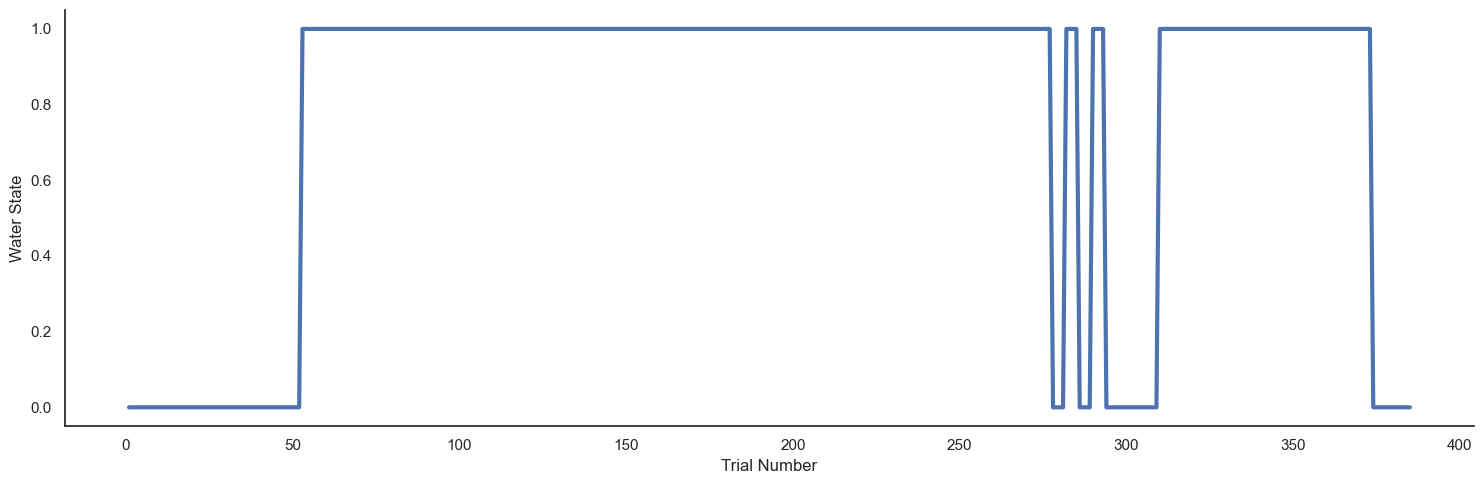

In [9]:
from src.plotting import plot_trial_schedule
g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)

In [ ]:
### SPEED 3.0 Trial Schedule

In [11]:
from src.add_phases import label_phases, df_add_phases

assert (df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=7,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_ST',
                                   'washout_ST',
                                   'washout_1_AT',
                                   'transfer_ST',
                                   'washout_2_AT'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,294,310,374]),
                        trial_hi = np.array([20,52,277,293,309,373,389])
)

In [13]:
df_labeled['water_speed_binary'].unique()

array([0])

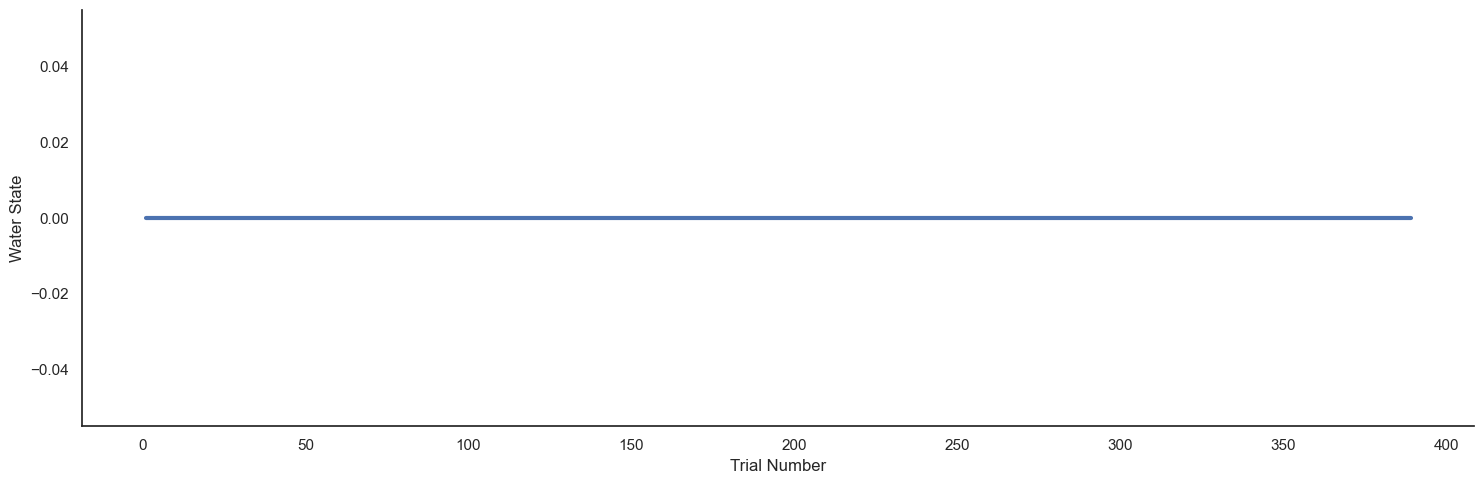

In [15]:
from src.plotting import plot_trial_schedule
g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)

In [19]:
# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')

crossed_threshold
True     6897
False      38
Name: count, dtype: int64
count                                                  6935
unique                                                 6935
top       0.000000_0.043654_0.086416_0.128321_0.169404_0...
freq                                                      1
Name: ball_pos_z, dtype: object
speed_label  experiment                      set_order
-2.0         TD_2.0M_spatial_generalization  AB           10
                                             BA            0
             TU_2.0M_spatial_generalization  AB            0
                                             BA            9
dtype: int64
                        experiment  ppid_full speed_label target_x_label  \
20  TD_2.0M_spatial_generalization  p001_neg2        -2.0            D30   
21  TD_2.0M_spatial_generalization  p001_neg2        -2.0            U60   
22  TD_2.0M_spatial_generalization  p001_neg2        -2.0            U30   
23  TD_2.0M_spatial_generalization  p001

C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


In [21]:
df_small_filt.head()

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
### APPLY PCA

In [27]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_small_filt,
            features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
            group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table


# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()

group_cols = ['water_speed_m_s','set_order','target_position_x_cm']

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x_cm',
                  target_z_col='target_position_z_cm',
                  features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
                  water_col = 'water_speed_m_s'
                 )
PCA_error_df

Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'trial_num_target', 'launch_deviation', 'launch_Speed',
       'ball_dist_to_center_cm', 'lateral_error_x_cm', 'depth_error_z_cm',
       'target_hit', 'water_speed_binary', 'water_speed_m_s', 'sign_label',
       'set_order', 'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_error_X_cm', 'PCA_error_Z_cm'],
      dtype='object')


C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
### SAVE PCA OUPUT DF

In [29]:

# Extract and join unique experiment strings
exp_tags = "_".join(df_labeled['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_labeled['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\{file_name}"

PCA_error_df.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

Saved: ..\data\PCA_error_TD_2.0M_spatial_generalization_TU_2.0M_spatial_generalization_speed_neg2_0_0_0.csv


In [29]:
from src.early_late_exposure import early_late_means

early_late_4_means = early_late_means(
                                            df_filt_BC,
                                            error_col='min_x_delta_BC', #baseline_corrected_dist
                                            window_size=4,
                                            ppid='ppid_full',
                                            phases = ['ST_training']
                                            )
early_late_4_means

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ppid,'phase','speed_label','target_x_label'])
C:\Users\jacob\water_current_MA\src\early_late_exposure.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ordered = (df_phase
C:\Users\jacob\water_current_MA\src\early_late_exposure.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  early_to_late.groupby

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)


ValueError: Could not interpret value `section` for `x`. An entry with this name does not appear in `data`.

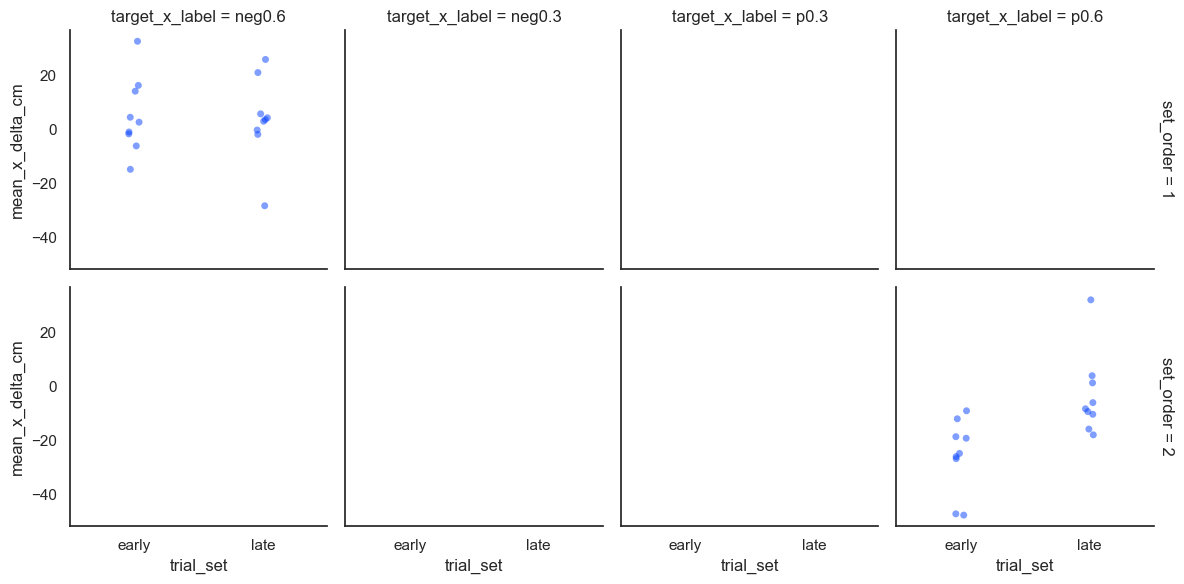

In [89]:
from src.plotting import plot_early_late_exposure

#early_late_4_means['training_status'].unique()

# if target doesnrt exist dont make facet...


plot_early_late_exposure(early_late_4_means,
                         y_col='mean_x_delta_cm',
                         cond_col='speed_label', 
                         ppid_col='ppid_full',
                         show_zero_line=True)

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

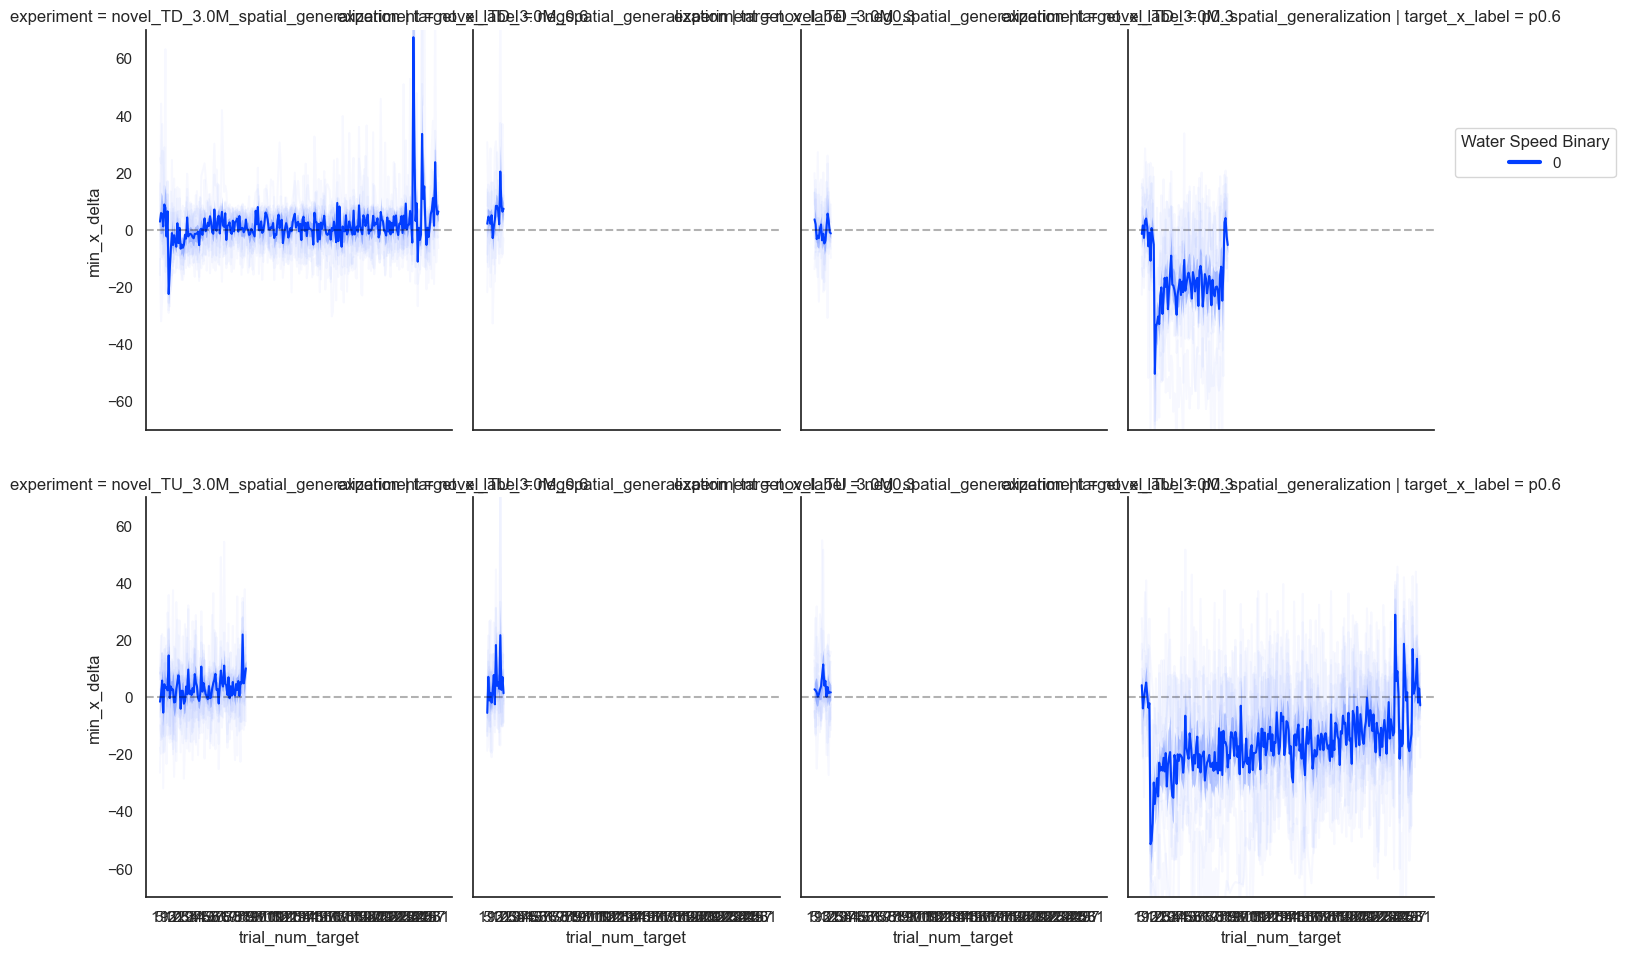

In [37]:
from src.plotting import plot_exposure_trials


plot_exposure_trials(df_filt_BC, 
                     cond_col='water_speed_binary',
                     ppid_col='ppid_full',
                     row_col='experiment',
                     y_col = 'min_x_delta', 
                     x_col='trial_num_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-70,70),
                     show_zero_line=True
                    )

In [ ]:
SINGLE-TARGET TRANSFER

In [82]:
df_filt_BC['phase'].unique

<bound method Series.unique of 0           baseline
1           baseline
2           baseline
3           baseline
4           baseline
            ...     
6810    washout_2_AT
6811    washout_2_AT
6812    washout_2_AT
6813    washout_2_AT
6814    washout_2_AT
Name: phase, Length: 6815, dtype: category
Categories (6, object): ['baseline', 'training_ST', 'transfer_ST', 'washout_1_AT', 'washout_2_AT', 'washout_ST']>

In [75]:
from src.filter_phase import filter_for_phase
df_current = filter_for_phase(df_filt_BC, phase_key='tr', inc_phase=True, ppid_col='ppid_full') 

C:\Users\jacob\water_current_MA\src\filter_phase.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  selected_phase['phase_trial_target'] = selected_phase.groupby([ppid_col, 'phase','target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\filter_phase.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_check = selected_phase.groupby([ppid_col,'target_x_label'])['phase_trial_target'].max()


In [77]:
df_training_retention = df_current[0].copy()

df_training_retention['phase'].unique()

['retention_ST_1', 'retention_ST_2', 'training_AT', 'training_ST']
Categories (9, object): ['baseline', 'retention_ST_1', 'retention_ST_2', 'training_AT', ..., 'washout_AT_1', 'washout_AT_2', 'washout_ST_1', 'washout_ST_2']

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

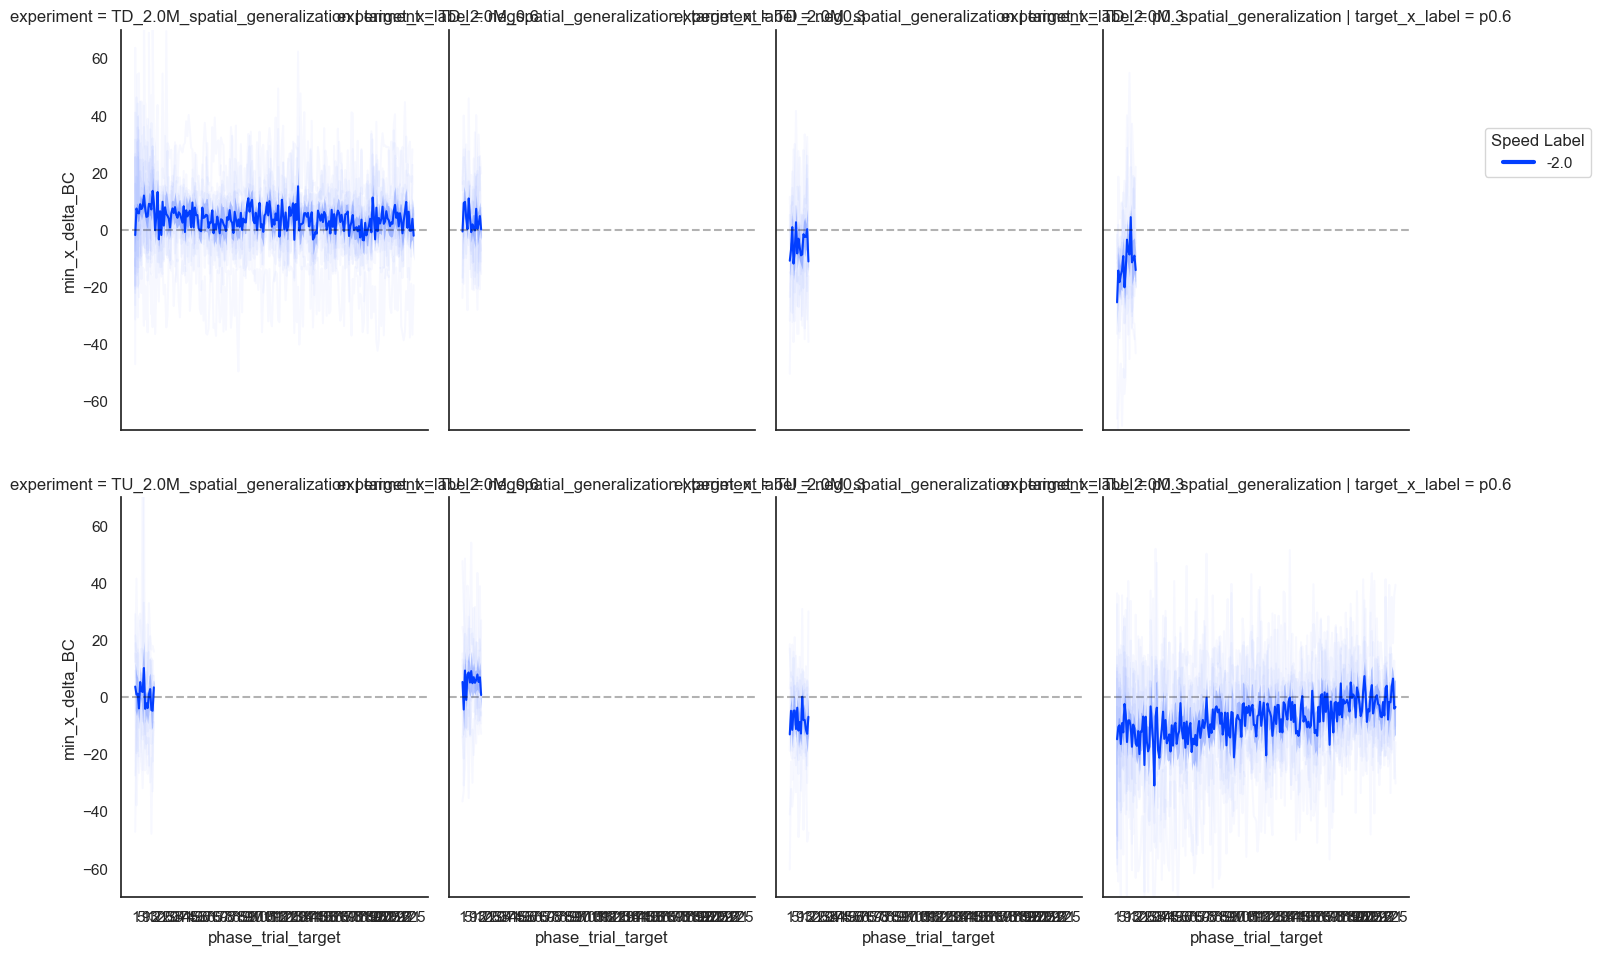

In [79]:
from src.plotting import plot_exposure_trials

plot_exposure_trials(df_training_retention, 
                     cond_col='speed_label',
                     ppid_col='ppid_full',
                     row_col='experiment',
                     y_col = 'min_x_delta_BC', 
                     x_col='phase_trial_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-70,70),
                     show_zero_line=True
                    )

In [117]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_training_retention,
            features = ['min_pos_from_target_x','min_pos_from_target_z'],
            group_cols = ['experiment','water_speed_m_s','target_x_label'], # set_order
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [119]:
df_angles = df_training_retention.copy()

group_cols = ['water_speed_m_s','target_x_label'] # set_order

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table[group_cols + new_cols], how="left", on=group_cols)
# should be true
#len(df_angles_v['pc_vector_1_angle'].unique()) == 16

In [121]:
df_angles_v['pc_vector_1_angle'].unique()
df_angles_v[['experiment', 'target_x_label', 'pc_vector_1_angle']].drop_duplicates()

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


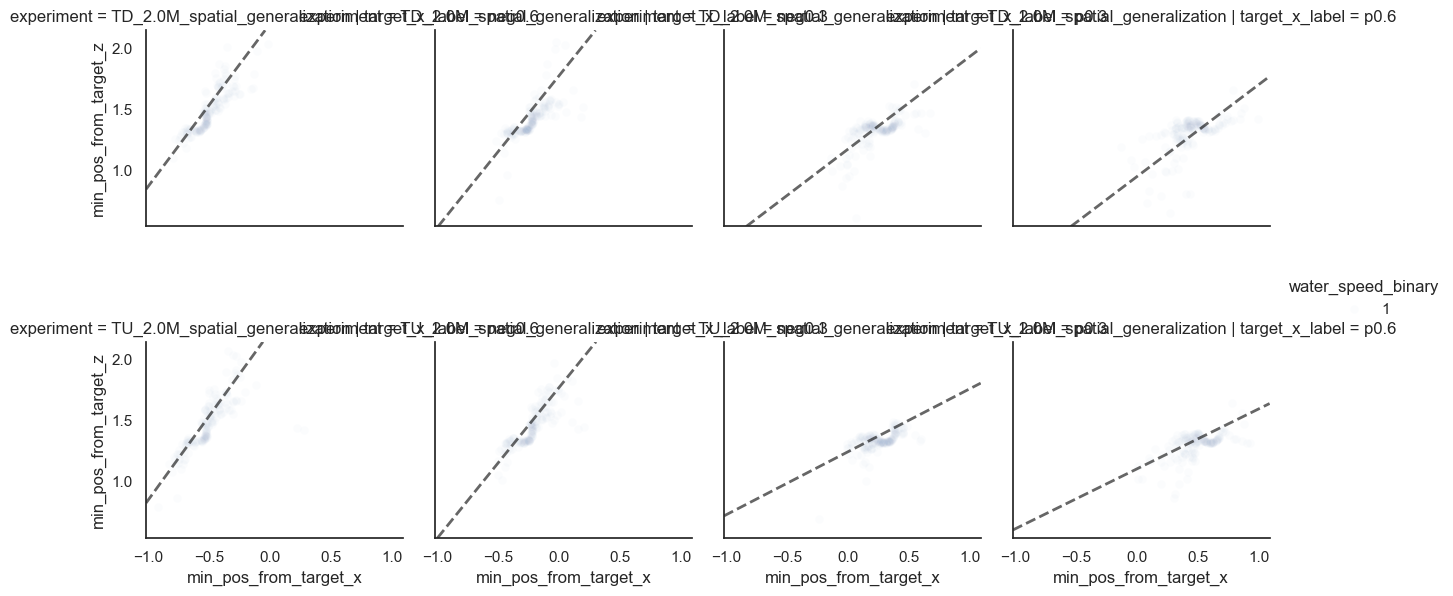

In [43]:
# -2.0 M/S

from src.plotting import plot_min_x_z

df_n2 = df_training_retention[df_training_retention['water_speed_m_s'] == -2.0].copy()

# slopes for n3 data
slope_key_n2 = np.array([[53.167841, 51.254056, 37.247702, 37.065538],
             [54.059303, 51.059116, 27.345653, 26.224002]])

plot_min_x_z(df_n2,
             show_slopes = True,
             slope_array = slope_key_n2,
             target_x_array = [-0.6, -0.3, 0.3, 0.6],
             c_col='target_x_label',
             r_col='experiment',
             hue_col = 'water_speed_binary'
            )

In [123]:
from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x',
                  target_z_col='target_position_z',
                  features = ['min_pos_from_target_x','min_pos_from_target_z'],
                  water_col = 'water_speed_m_s'
                 )

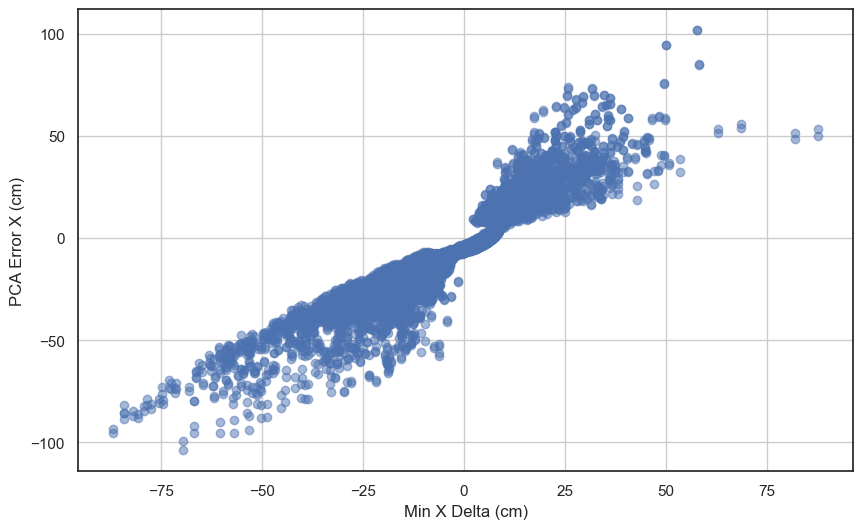

In [125]:
plt.figure(figsize=(10,6))
plt.scatter(PCA_error_df['min_x_delta'], PCA_error_df['PCA_error_X_cm'], alpha=0.5)

plt.xlabel('Min X Delta (cm)')
plt.ylabel('PCA Error X (cm)')
plt.grid(True)
plt.show() 

In [127]:
# using geometric error (min_x_delta) we will baseline correct the PCA derived measure
baseline_lookup = baseline_filt.groupby(['ppid_full', 'target_x_label'])['mean_ball_dist_x_cm'].mean().reset_index()
# combine baseline error back to main df
PCA_error_df_bt = PCA_error_df.merge(baseline_lookup, on=['ppid_full', 'target_x_label'], how='left').copy()

PCA_error_df_bt['PCA_error_X_cm_BC'] = PCA_error_df_bt['PCA_error_X_cm'] - PCA_error_df_bt['mean_ball_dist_x_cm_y']

C:\Users\jacob\AppData\Local\Temp\ipykernel_3112\2186487001.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baseline_lookup = baseline_filt.groupby(['ppid_full', 'target_x_label'])['mean_ball_dist_x_cm'].mean().reset_index()


In [133]:
PCA_error_df_bt['water_speed_m_s'].unique()

array([-2.])

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

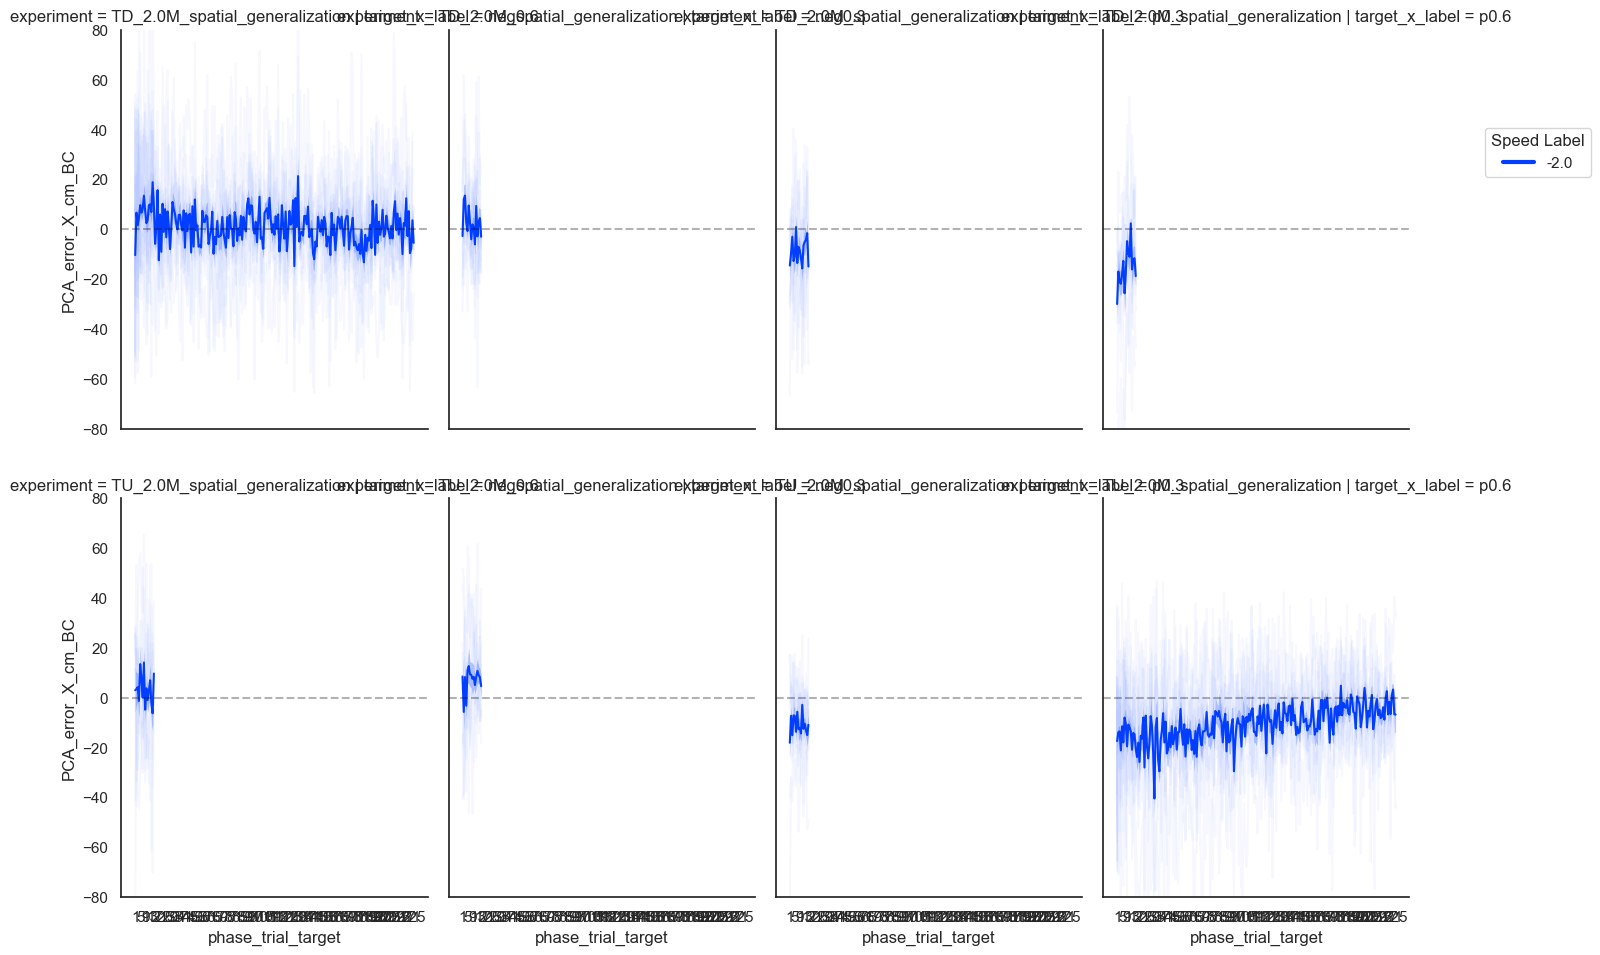

In [131]:
from src.plotting import plot_exposure_trials

# baseline corrected
plot_exposure_trials(PCA_error_df_bt, 
                     row_col='experiment',
                     cond_col='speed_label',
                     ppid_col='ppid_full',
                     y_col = 'PCA_error_X_cm_BC', 
                     x_col='phase_trial_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-80,80),
                     show_zero_line=True
                    )

In [137]:
PCA_error_df_bt.to_csv(r"..\data\df_PCA_current.csv", index=False)

In [ ]:
# ALL MOVING-WATER

In [103]:
# ALL MOVING-WATER
df_water_current = df_filt_BC[df_filt_BC['water_speed_binary'] != 0.0]

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


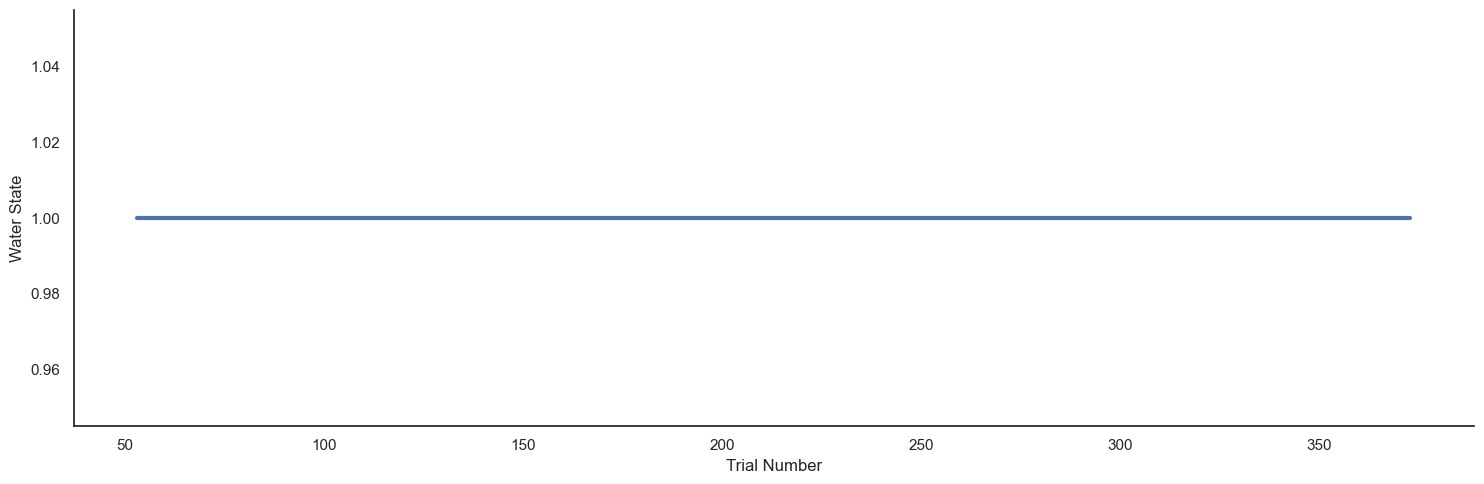

In [105]:
from src.plotting import plot_trial_schedule
g = plot_trial_schedule(df_water_current, y_col='water_speed_binary', context='poster', font_scale=3)

In [109]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_water_current,
            features = ['min_pos_from_target_x','min_pos_from_target_z'],
            group_cols = ['experiment','water_speed_m_s','target_x_label'], # set_order
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table

C:\Users\jacob\water_current_MA\src\PCA.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data_current.groupby(group_cols)


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


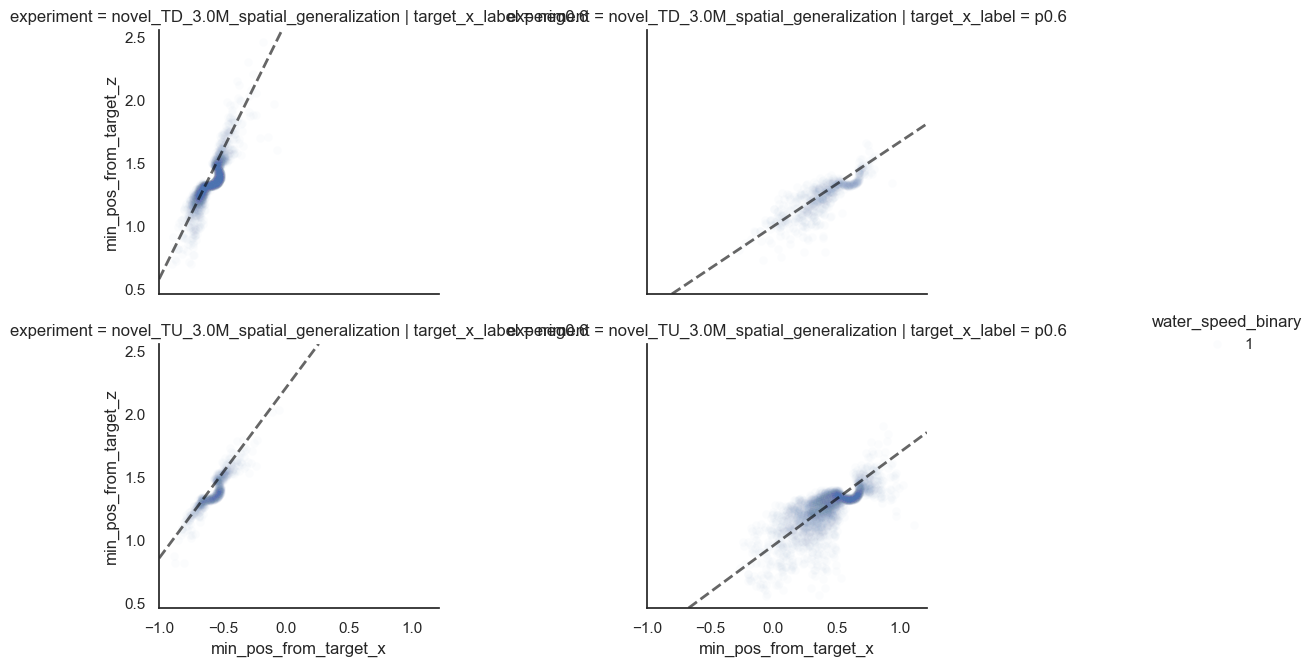

In [115]:
# -3.0 M/S

from src.plotting import plot_min_x_z

df_n3 = df_water_current[df_water_current['water_speed_m_s'] == -3.0].copy()

# slopes for n3 data
slope_key_n3 = np.array([[63.733853, 33.710848],
             [53.336088, 36.385904]])

plot_min_x_z(df_n3,
             show_slopes = True,
             slope_array = slope_key_n3,
             target_x_array = [-0.6, 0.6],
             c_col='target_x_label',
             r_col='experiment',
             hue_col = 'water_speed_binary'
            )

In [117]:
df_angles = df_post_baseline.copy()

group_cols = ['experiment', 'water_speed_m_s','target_x_label'] # set_order

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table[group_cols + new_cols], how="left", on=group_cols)
# should be true
#len(df_angles_v['pc_vector_1_angle'].unique()) == 16

In [121]:
from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x',
                  target_z_col='target_position_z',
                  features = ['min_pos_from_target_x','min_pos_from_target_z'],
                  water_col = 'water_speed_m_s'
                 )

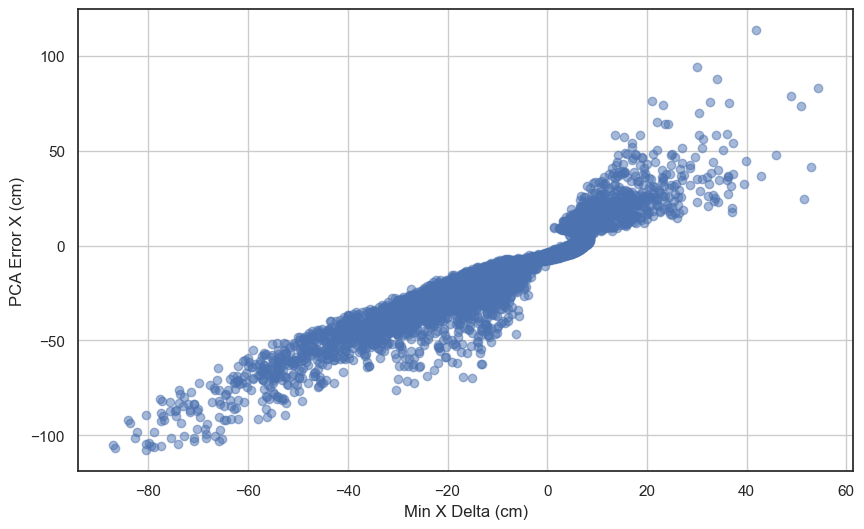

In [123]:

plt.figure(figsize=(10,6))
plt.scatter(PCA_error_df['min_x_delta'], PCA_error_df['PCA_error_X_cm'], alpha=0.5)

plt.xlabel('Min X Delta (cm)')
plt.ylabel('PCA Error X (cm)')
plt.grid(True)
plt.show() 

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

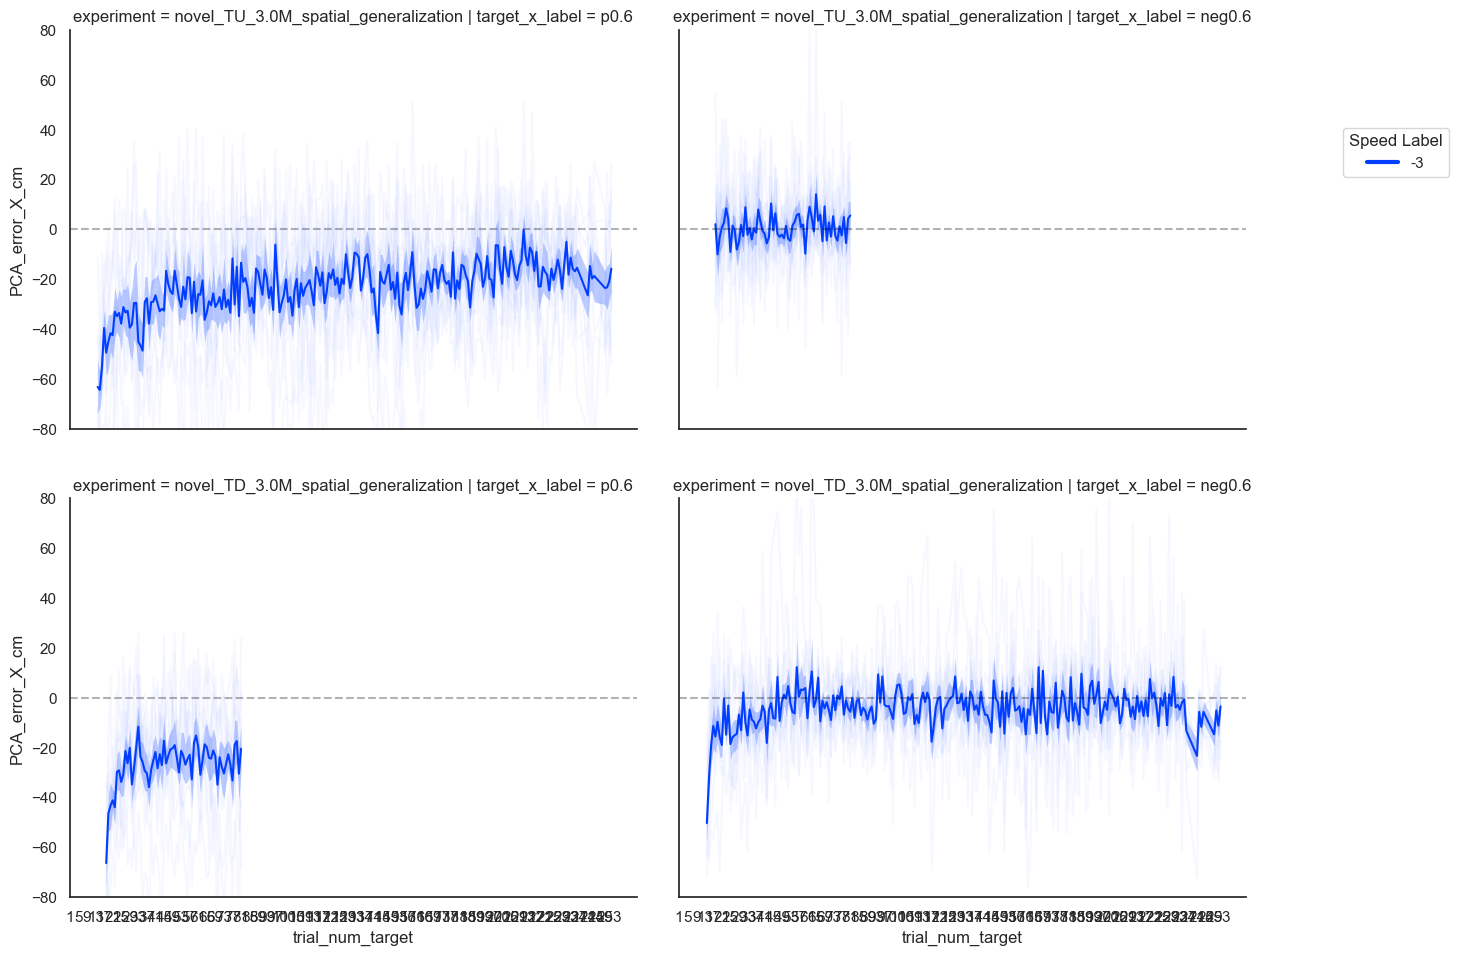

In [127]:
from src.plotting import plot_exposure_trials

# raw data
plot_exposure_trials(PCA_error_df, 
                     row_col='experiment',
                     cond_col='speed_label',
                     ppid_col='ppid_full',
                     y_col = 'PCA_error_X_cm', 
                     x_col='trial_num_target',
                     context='poster', 
                     font_scale=3,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-80,80),
                     show_zero_line=True
                    )

In [131]:
PCA_error_df.to_csv(r"..\data\df_PCA_current.csv", index=False)